# Appendix D: Review of Differential Equations

**Source Span.** John M. Lee, *Introduction to Smooth Manifolds*, Appendix D, printed pages 663-683. The appendix body is concentrated on printed pages 663-674, with the extraction window `pdftotext -f 681 -l 695` also reaching references and backmatter.

**Chapter goal.** Turn the ODE facts used later for manifold vector fields into inspectable computations: first-order systems, local existence from a contraction, uniqueness from comparison estimates, smooth dependence on initial data, autonomous lifts of time-dependent systems, phase portraits for `2x2` linear systems, and the partial group law of local flows.

This notebook uses the source only for structure and terminology. The examples, prose, code, diagrams, and checks below are original computational translations.


In [1]:
from pathlib import Path
import csv
import json
import math
import sys
import warnings

import matplotlib.pyplot as plt
from matplotlib import cm
import networkx as nx
import numpy as np
import plotly.graph_objects as go
from scipy.integrate import solve_ivp
from scipy.linalg import expm
import sympy as sp

warnings.filterwarnings("ignore", category=UserWarning)


def locate_book_root():
    candidates = [Path.cwd(), *Path.cwd().parents, Path.cwd() / "Introduction-to-Smooth-Manifolds"]
    for candidate in candidates:
        if (candidate / "AGENTS.md").exists() and (candidate / "utils").exists():
            return candidate.resolve()
    raise RuntimeError("Could not locate Introduction-to-Smooth-Manifolds book root")


BOOK_ROOT = locate_book_root()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    assert_artifacts,
    chapter_artifact_root,
    display_artifact,
    save_csv,
    save_json,
    save_matplotlib,
)

UNIT_KEY = "appendix-d-review-of-differential-equations"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
HTML = ARTIFACT_ROOT / "html"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

generated_artifacts = []
check_paths = []


def rel(path):
    return Path(path).resolve().relative_to(BOOK_ROOT).as_posix()


def remember(path):
    path = Path(path)
    generated_artifacts.append(path)
    return path


def remember_check(path):
    path = Path(path)
    check_paths.append(path)
    return path


def save_figure(fig, filename, *, dpi=160):
    path = FIGURES / filename
    save_matplotlib(fig, path, dpi=dpi)
    plt.close(fig)
    return remember(path)


def save_check(data, filename):
    return remember_check(save_json(data, CHECKS / filename))


def save_table(rows, filename):
    return remember(save_csv(rows, TABLES / filename))


def save_plotly_standalone(fig, filename):
    path = HTML / filename
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.write_html(str(path), include_plotlyjs=True, full_html=True)
    return remember(path)


def quiver_field(ax, xlim, ylim, rhs, *, density=18, color="#64748b", scale=28):
    xs = np.linspace(xlim[0], xlim[1], density)
    ys = np.linspace(ylim[0], ylim[1], density)
    X, Y = np.meshgrid(xs, ys)
    U, V = rhs(X, Y)
    speed = np.sqrt(U**2 + V**2)
    U = np.divide(U, speed, out=np.zeros_like(U), where=speed > 1e-12)
    V = np.divide(V, speed, out=np.zeros_like(V), where=speed > 1e-12)
    ax.quiver(X, Y, U, V, color=color, alpha=0.62, scale=scale, width=0.003)


print(f"Book root: {BOOK_ROOT}")
print(f"Artifact root: {rel(ARTIFACT_ROOT)}")


Book root: D:\Geometry\Introduction-to-Smooth-Manifolds
Artifact root: artifacts/appendix-d-review-of-differential-equations


## Visual Storyboard

| Sequence | Appendix D anchor | Representation | Inspection target | Validation |
| --- | --- | --- | --- | --- |
| 1 | First-order autonomous and nonautonomous systems | Vector fields with integral curves | A curve is a solution only when its velocity equals the field at the current time and state | Symbolic residual for rotation and solver status |
| 2 | Local existence under locally Lipschitz hypotheses | Picard iterates for an integral operator | Successive curves become uniformly closer when `L * epsilon < 1` | Observed contraction ratios and final solver comparison |
| 3 | Why uniqueness needs Lipschitz control | Non-Lipschitz delayed solutions from one initial value | Same initial data can branch when the field is not locally Lipschitz | Residual away from branch times and shared initial value |
| 4 | Comparison theorem and Gronwall estimate | Actual separation versus exponential bound | The bound is deliberately coarser than the solution but traps it for all plotted times | Nonpositive bound violation |
| 5 | Smooth dependence | Solution surface `Phi(t,c)` and variational derivative | Vary the initial point and watch the solution change smoothly | Symbolic variational equation and finite-difference derivative check |
| 6 | Nonautonomous to autonomous lift | Curve in extended `(s,x,y)` space | The added clock coordinate makes a time-dependent system autonomous | Lift/original coordinate agreement |
| 7 | `2x2` constant-coefficient linear systems | Phase portraits plus trace-determinant classifier | Eigenvalue type predicts the visible portrait | Matrix exponential residuals |
| 8 | Flows and maximal intervals | Local flow of `x' = x^2` | Composition is valid only where both sides are defined | Symbolic flow law and numeric composition error |


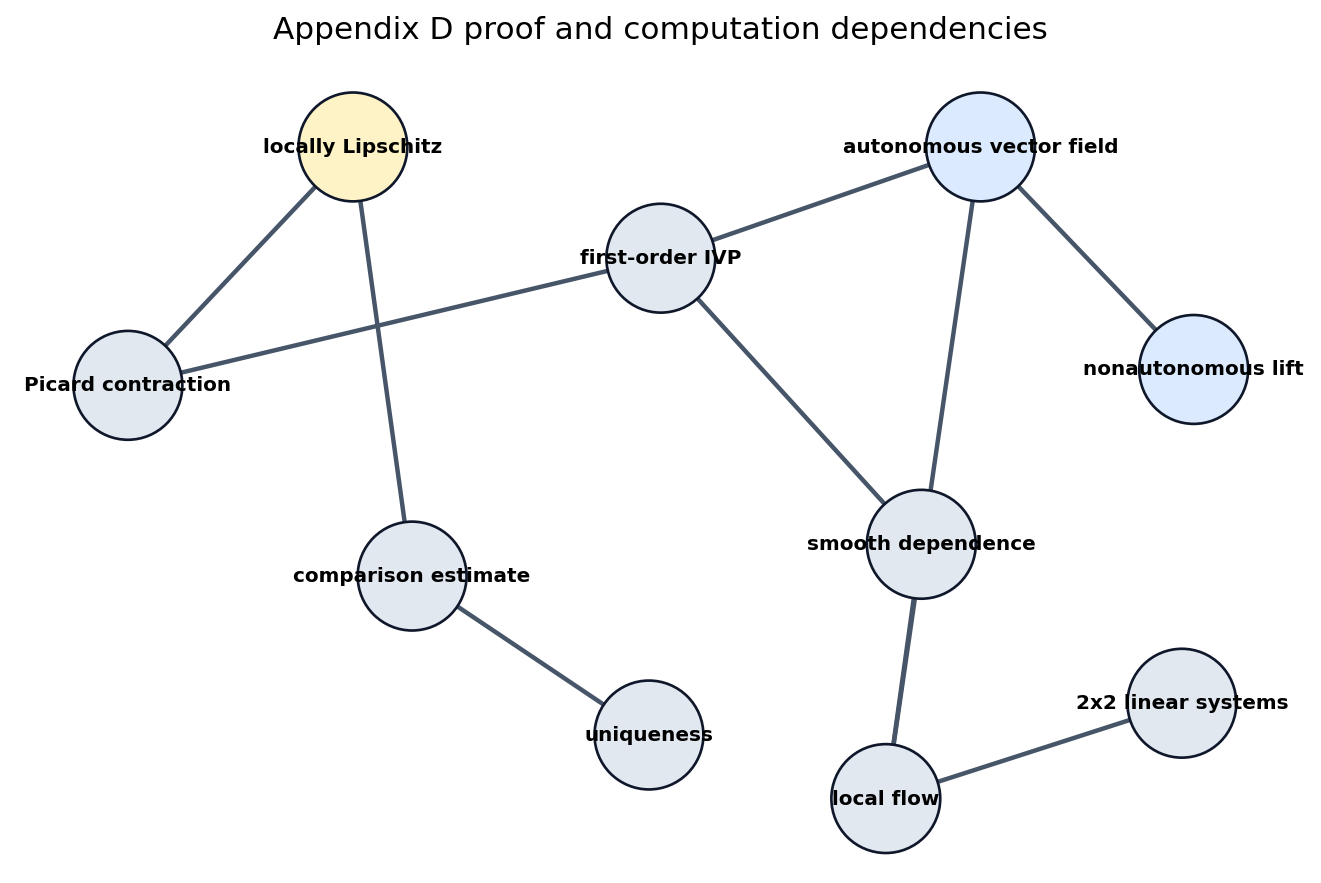

[appendix-d-library-routing.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/appendix-d-review-of-differential-equations/tables/appendix-d-library-routing.csv)

In [2]:
storyboard_nodes = [
    "first-order IVP",
    "autonomous vector field",
    "locally Lipschitz",
    "Picard contraction",
    "comparison estimate",
    "uniqueness",
    "smooth dependence",
    "nonautonomous lift",
    "2x2 linear systems",
    "local flow",
]
storyboard_edges = [
    ("first-order IVP", "autonomous vector field"),
    ("autonomous vector field", "local flow"),
    ("locally Lipschitz", "Picard contraction"),
    ("Picard contraction", "first-order IVP"),
    ("comparison estimate", "uniqueness"),
    ("locally Lipschitz", "comparison estimate"),
    ("first-order IVP", "smooth dependence"),
    ("smooth dependence", "local flow"),
    ("nonautonomous lift", "autonomous vector field"),
    ("2x2 linear systems", "local flow"),
]

pos = {
    "first-order IVP": (0.0, 0.55),
    "autonomous vector field": (1.35, 0.9),
    "locally Lipschitz": (-1.3, 0.9),
    "Picard contraction": (-2.25, 0.15),
    "comparison estimate": (-1.05, -0.45),
    "uniqueness": (-0.05, -0.95),
    "smooth dependence": (1.1, -0.35),
    "nonautonomous lift": (2.25, 0.2),
    "2x2 linear systems": (2.2, -0.85),
    "local flow": (0.95, -1.15),
}
G = nx.DiGraph()
G.add_nodes_from(storyboard_nodes)
G.add_edges_from(storyboard_edges)

fig, ax = plt.subplots(figsize=(10.4, 6.4))
nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>", width=2.0, edge_color="#475569", arrowsize=18)
node_colors = ["#fef3c7" if "Lipschitz" in n else "#dbeafe" if n in {"autonomous vector field", "nonautonomous lift"} else "#e2e8f0" for n in G.nodes]
nx.draw_networkx_nodes(G, pos, ax=ax, node_size=2400, node_color=node_colors, edgecolors="#0f172a", linewidths=1.2)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=9, font_weight="bold")
ax.set_title("Appendix D proof and computation dependencies", fontsize=14, pad=18)
ax.axis("off")
dependency_path = save_figure(fig, "appendix-d-ode-dependency-storyboard.png")

routing_rows = [
    {"concept": "planar vector fields and integral curves", "representation": "quiver fields with solve_ivp trajectories", "library": "Matplotlib + SciPy", "why": "the geometry is two-dimensional and solution curves must be compared directly to arrows"},
    {"concept": "Picard contraction", "representation": "iterated integral operator and sup-norm ratios", "library": "NumPy + Matplotlib", "why": "the contraction estimate is a metric-space statement on curves"},
    {"concept": "comparison and uniqueness", "representation": "separation plots and Gronwall envelopes", "library": "SciPy + Matplotlib", "why": "numerical trajectories make the exponential bound inspectable"},
    {"concept": "smooth dependence", "representation": "solution surface and variational derivative", "library": "Plotly + SymPy", "why": "the surface is best inspected interactively while the derivative identity is exact"},
    {"concept": "nonautonomous lift", "representation": "extended-space trajectory", "library": "SciPy + Matplotlib 3D", "why": "the added clock coordinate is a geometric curve in one higher dimension"},
    {"concept": "2x2 linear systems", "representation": "phase portraits and trace-determinant classifier", "library": "SciPy linear algebra + Plotly", "why": "matrix exponentials and eigenvalue regions are the natural computational model"},
    {"concept": "local flows and maximal intervals", "representation": "symbolic flow law and blow-up domain", "library": "SymPy + Matplotlib", "why": "the partial group law is exact but its domain is geometric"},
]
routing_path = save_table(routing_rows, "appendix-d-library-routing.csv")
storyboard_check_path = save_check(
    {
        "source_span": "Appendix D, printed pages 663-683; appendix body read from extraction window PDF pages 681-695",
        "nodes": storyboard_nodes,
        "edges": storyboard_edges,
        "visual_count": 8,
        "routing_libraries": sorted({row["library"] for row in routing_rows}),
    },
    "appendix-d-storyboard.json",
)

display_artifact(dependency_path, width=900)
display_artifact(routing_path)


## Computational Translation Guide and Library Routing

| Appendix language | Computational object | What to inspect |
| --- | --- | --- |
| First-order system `y'(t)=V(t,y(t))` | Python function `rhs(t, y)` returning a vector | The state derivative has the same shape as the state |
| Autonomous system | `rhs(t, y)` ignores `t`, or a vector field `V(y)` | Arrows in state space do not change with time |
| Nonautonomous system | `rhs(t, y)` genuinely uses `t` | The same point can have different arrows at different times |
| Locally Lipschitz hypothesis | A local bound `|V(y)-V(z)| <= L |y-z|` | Choose the time window so `L * epsilon < 1` for Picard contraction |
| Comparison/Gronwall estimate | Scalar envelope for a separation norm | The envelope controls solutions without solving the original system exactly |
| Smooth dependence | Flow map `Phi(t,c)` and sensitivity `dPhi/dc` | The derivative solves a variational equation along the solution |
| Nonautonomous lift | Add clock state `s' = 1` | The lifted vector field is autonomous on extended space |
| Local flow | Partial map `Phi_t(x)` | The composition law only holds when every intermediate point is defined |


## First-Order Systems and Integral Curves

The appendix starts with first-order systems because manifold vector fields become ODEs after choosing local coordinates. The basic test is direct: a proposed curve is an integral curve when its velocity equals the vector field at the curve point. The left panel uses the autonomous rotation field. The right panel uses a time-dependent scalar equation drawn in the `(t,y)` plane, where arrows encode `(dt/dtau, dy/dtau) = (1, V(t,y))`.


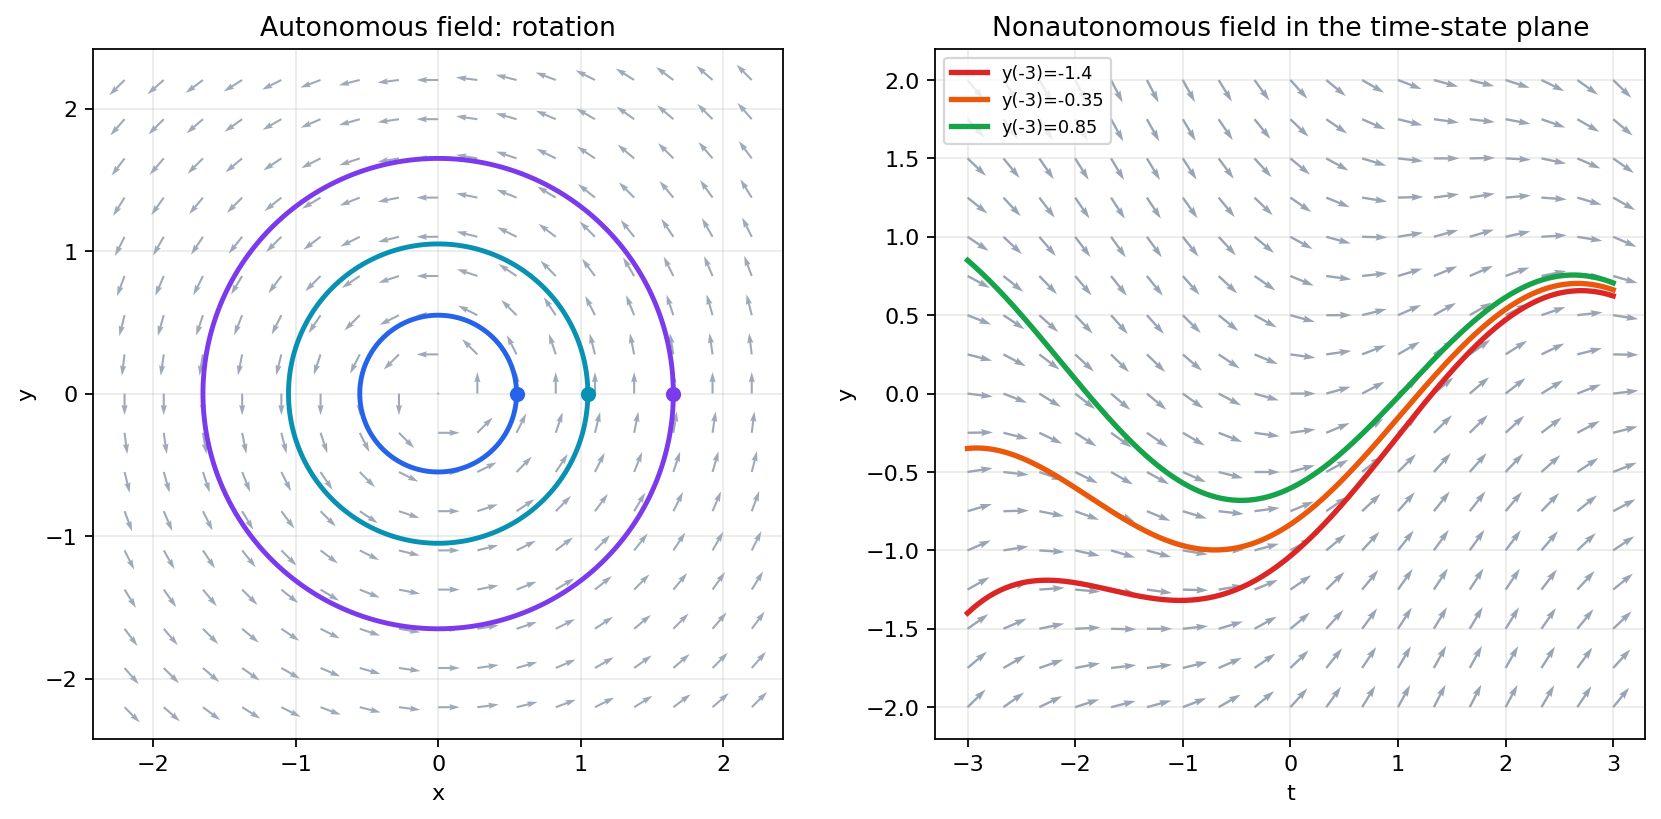

In [3]:
t_sym, a_sym, b_sym = sp.symbols("t a b", real=True)
gamma_rotation = sp.Matrix([
    a_sym * sp.cos(t_sym) - b_sym * sp.sin(t_sym),
    a_sym * sp.sin(t_sym) + b_sym * sp.cos(t_sym),
])
rotation_residual = sp.simplify(gamma_rotation.diff(t_sym) - sp.Matrix([-gamma_rotation[1], gamma_rotation[0]]))
assert rotation_residual == sp.Matrix([0, 0])

def rotation_rhs(t, z):
    return np.array([-z[1], z[0]])


def forced_scalar_rhs(t, y):
    return np.array([-0.55 * y[0] + 0.85 * np.sin(t)])


fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.6))

ax = axes[0]
quiver_field(ax, (-2.2, 2.2), (-2.2, 2.2), lambda X, Y: (-Y, X), density=17, scale=32)
theta = np.linspace(0, 2 * np.pi, 220)
for radius, color in [(0.55, "#2563eb"), (1.05, "#0891b2"), (1.65, "#7c3aed")]:
    ax.plot(radius * np.cos(theta), radius * np.sin(theta), color=color, lw=2.2)
    ax.scatter([radius], [0], color=color, s=34, zorder=4)
ax.set_title("Autonomous field: rotation")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_aspect("equal")
ax.grid(alpha=0.25)

ax = axes[1]
T, Y = np.meshgrid(np.linspace(-3.0, 3.0, 19), np.linspace(-2.0, 2.0, 17))
U = np.ones_like(T)
V = -0.55 * Y + 0.85 * np.sin(T)
speed = np.sqrt(U**2 + V**2)
ax.quiver(T, Y, U / speed, V / speed, color="#64748b", alpha=0.65, scale=28)
for y0, color in [(-1.4, "#dc2626"), (-0.35, "#ea580c"), (0.85, "#16a34a")]:
    sol = solve_ivp(forced_scalar_rhs, (-3, 3), [y0], t_eval=np.linspace(-3, 3, 240), rtol=1e-9, atol=1e-11)
    assert sol.success
    ax.plot(sol.t, sol.y[0], color=color, lw=2.4, label=f"y(-3)={y0:g}")
ax.set_title("Nonautonomous field in the time-state plane")
ax.set_xlabel("t")
ax.set_ylabel("y")
ax.grid(alpha=0.25)
ax.legend(loc="upper left", fontsize=8)

vector_field_path = save_figure(fig, "appendix-d-vector-fields-integral-curves.png")
vector_field_check_path = save_check(
    {
        "rotation_symbolic_residual": [str(entry) for entry in rotation_residual],
        "forced_scalar_solver": "solve_ivp with rtol=1e-9, atol=1e-11",
        "inspection": "autonomous arrows depend only on state; nonautonomous arrows depend on t and y",
    },
    "appendix-d-vector-field-checks.json",
)
display_artifact(vector_field_path, width=900)


## Local Existence as a Picard Contraction

For an autonomous equation `y' = V(y)`, existence is proved by rewriting the IVP as a fixed point problem for the integral operator

`I(y)(t) = c + integral_0^t V(y(s)) ds`.

On a short interval, a Lipschitz constant `L` for `V` gives `||I(y)-I(z)|| <= L epsilon ||y-z||`. The plot below iterates this operator for `y' = sin(y)`, `y(0)=0.8`, on an interval where `L epsilon < 1`.


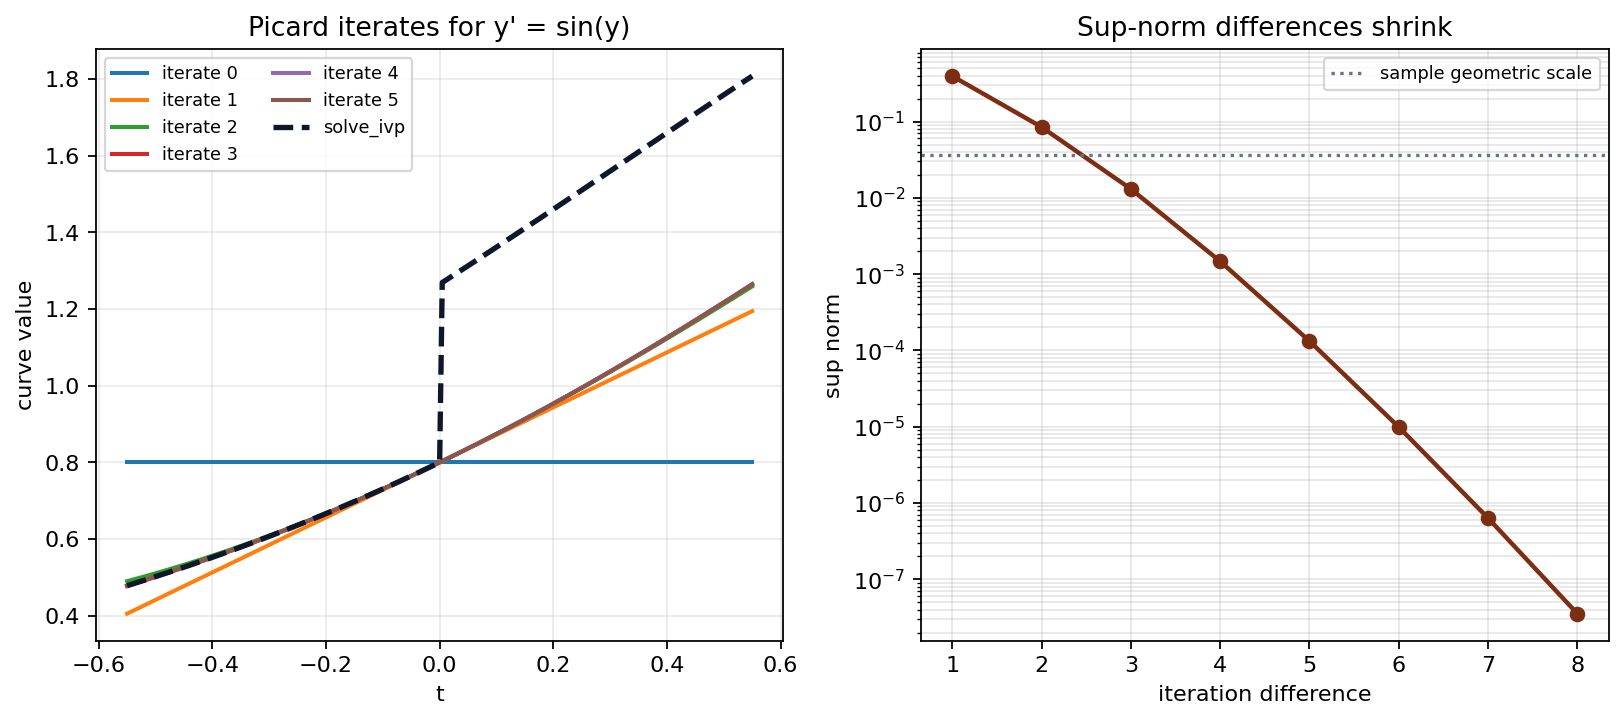

In [4]:
def integral_from_zero(t_grid, values):
    t_grid = np.asarray(t_grid)
    values = np.asarray(values)
    out = np.zeros_like(values, dtype=float)
    zero_idx = int(np.argmin(np.abs(t_grid)))
    if abs(t_grid[zero_idx]) > 1e-12:
        raise ValueError("t_grid must contain 0")
    for k in range(zero_idx + 1, len(t_grid)):
        out[k] = out[k - 1] + 0.5 * (values[k - 1] + values[k]) * (t_grid[k] - t_grid[k - 1])
    for k in range(zero_idx - 1, -1, -1):
        out[k] = out[k + 1] - 0.5 * (values[k + 1] + values[k]) * (t_grid[k + 1] - t_grid[k])
    return out


epsilon = 0.55
L_bound = 1.0
c0 = 0.8
t_grid = np.linspace(-epsilon, epsilon, 241)
picard_curves = [np.full_like(t_grid, c0, dtype=float)]
for _ in range(8):
    picard_curves.append(c0 + integral_from_zero(t_grid, np.sin(picard_curves[-1])))

picard_diffs = [
    float(np.max(np.abs(picard_curves[k + 1] - picard_curves[k])))
    for k in range(len(picard_curves) - 1)
]
picard_ratios = [
    picard_diffs[k + 1] / picard_diffs[k]
    for k in range(len(picard_diffs) - 1)
    if picard_diffs[k] > 1e-14
]
observed_max_ratio = float(max(picard_ratios))
assert observed_max_ratio < L_bound * epsilon + 0.03

sol = solve_ivp(lambda t, y: np.sin(y), (-epsilon, epsilon), [c0], t_eval=t_grid[t_grid >= 0], rtol=1e-10, atol=1e-12)
sol_back = solve_ivp(lambda t, y: np.sin(y), (0, -epsilon), [c0], t_eval=t_grid[t_grid <= 0][::-1], rtol=1e-10, atol=1e-12)
reference = np.empty_like(t_grid)
reference[t_grid >= 0] = sol.y[0]
reference[t_grid <= 0] = sol_back.y[0][::-1]
picard_final_error = float(np.max(np.abs(picard_curves[-1] - reference)))

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.8))
for k, yk in enumerate(picard_curves[:6]):
    axes[0].plot(t_grid, yk, lw=1.8, label=f"iterate {k}")
axes[0].plot(t_grid, reference, color="#0f172a", lw=2.4, ls="--", label="solve_ivp")
axes[0].set_title("Picard iterates for y' = sin(y)")
axes[0].set_xlabel("t")
axes[0].set_ylabel("curve value")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8, ncol=2)

axes[1].semilogy(range(1, len(picard_diffs) + 1), picard_diffs, marker="o", color="#7c2d12", lw=2)
axes[1].axhline(picard_diffs[0] * (L_bound * epsilon) ** 4, color="#64748b", ls=":", label="sample geometric scale")
axes[1].set_title("Sup-norm differences shrink")
axes[1].set_xlabel("iteration difference")
axes[1].set_ylabel("sup norm")
axes[1].grid(alpha=0.3, which="both")
axes[1].legend(fontsize=8)

picard_path = save_figure(fig, "appendix-d-picard-contraction-diagnostic.png")
picard_check_path = save_check(
    {
        "equation": "y' = sin(y), y(0)=0.8",
        "epsilon": epsilon,
        "lipschitz_bound": L_bound,
        "contraction_bound_L_epsilon": L_bound * epsilon,
        "observed_max_ratio": observed_max_ratio,
        "final_error_against_solve_ivp": picard_final_error,
        "sup_norm_differences": picard_diffs,
    },
    "appendix-d-picard-contraction-check.json",
)
display_artifact(picard_path, width=900)


## Uniqueness and a Locally Lipschitz Failure Mode

The uniqueness theorem uses local Lipschitz control to keep two solutions from separating after they meet. A useful warning example is `y' = 2 sqrt(|y|)`, `y(0)=0`: it is continuous but not locally Lipschitz at the origin. The delayed family below shares the same initial value and then branches.


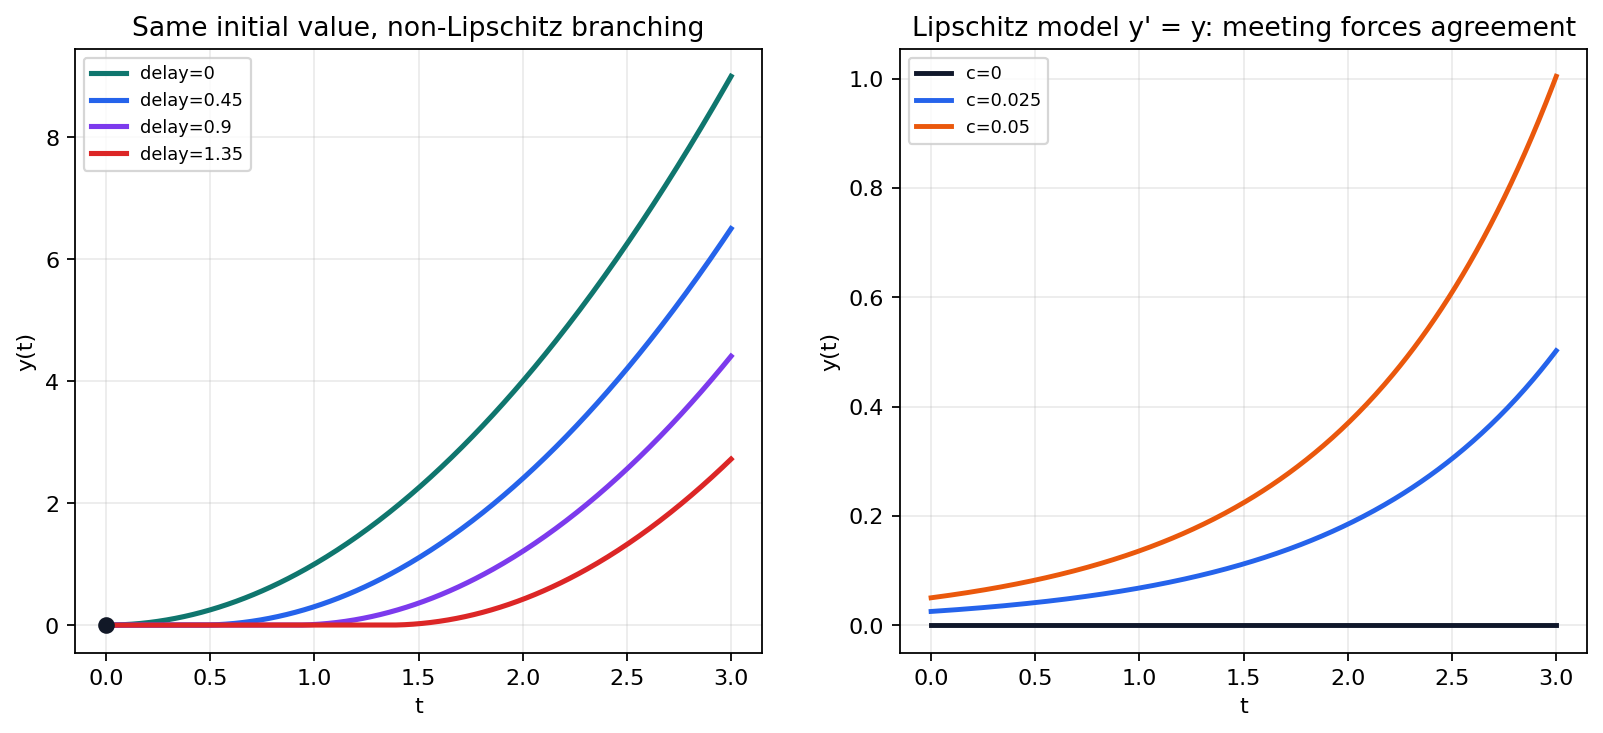

In [5]:
t_nonlip = np.linspace(0, 3.0, 361)
delays = [0.0, 0.45, 0.9, 1.35]

def delayed_solution(t_values, delay):
    t_values = np.asarray(t_values)
    return np.where(t_values <= delay, 0.0, (t_values - delay) ** 2)


def delayed_rhs(y_values):
    return 2.0 * np.sqrt(np.abs(y_values))


residuals = []
fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.9))
for delay, color in zip(delays, ["#0f766e", "#2563eb", "#7c3aed", "#dc2626"]):
    y_vals = delayed_solution(t_nonlip, delay)
    axes[0].plot(t_nonlip, y_vals, color=color, lw=2.3, label=f"delay={delay:g}")
    mask = t_nonlip > delay + 0.03
    derivative = 2.0 * (t_nonlip[mask] - delay)
    residuals.append(float(np.max(np.abs(derivative - delayed_rhs(y_vals[mask])))))
axes[0].scatter([0], [0], color="#111827", s=42, zorder=4)
axes[0].set_title("Same initial value, non-Lipschitz branching")
axes[0].set_xlabel("t")
axes[0].set_ylabel("y(t)")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

nearby_initials = [0.0, 0.025, 0.05]
for c, color in zip(nearby_initials, ["#0f172a", "#2563eb", "#ea580c"]):
    axes[1].plot(t_nonlip, c * np.exp(t_nonlip), color=color, lw=2.2, label=f"c={c:g}")
axes[1].set_title("Lipschitz model y' = y: meeting forces agreement")
axes[1].set_xlabel("t")
axes[1].set_ylabel("y(t)")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

uniqueness_path = save_figure(fig, "appendix-d-uniqueness-lipschitz-failure.png")
uniqueness_check_path = save_check(
    {
        "non_lipschitz_equation": "y' = 2 sqrt(|y|)",
        "shared_initial_value": all(abs(delayed_solution(np.array([0.0]), d)[0]) < 1e-14 for d in delays),
        "delayed_solution_residuals_away_from_branch_times": residuals,
        "max_residual": float(max(residuals)),
        "interpretation": "continuous but not locally Lipschitz at y=0, so the uniqueness theorem does not apply",
    },
    "appendix-d-uniqueness-lipschitz-failure-check.json",
)
display_artifact(uniqueness_path, width=900)


## Comparison and Gronwall Bounds

The comparison theorem turns a vector inequality into a scalar barrier. In the common Lipschitz case, if two solutions satisfy `|u'| <= L |u|`, the scalar comparison solution is the Gronwall envelope `|u(0)| exp(L |t|)`. The barrier below is intentionally conservative; the point is that it is guaranteed by the hypothesis.


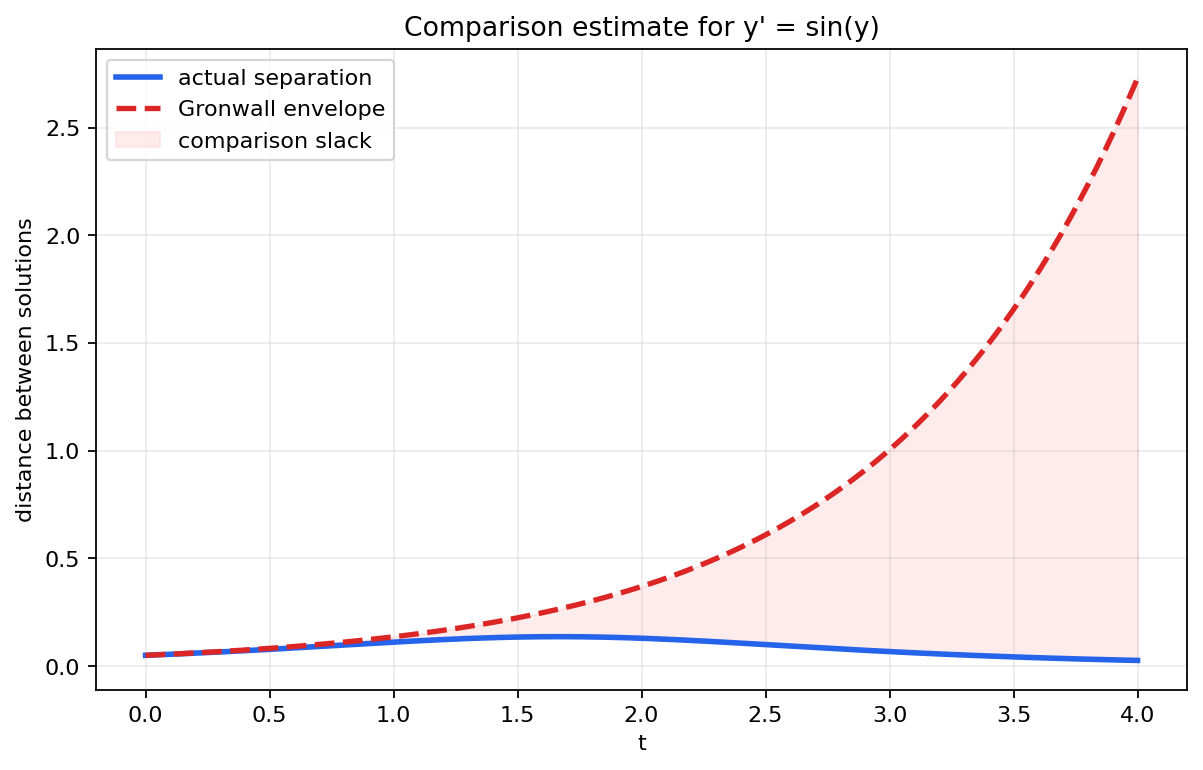

In [6]:
def sin_solution(c, t_eval):
    sol = solve_ivp(lambda t, y: np.sin(y), (t_eval[0], t_eval[-1]), [c], t_eval=t_eval, rtol=1e-10, atol=1e-12)
    if not sol.success:
        raise RuntimeError(sol.message)
    return sol.y[0]


t_compare = np.linspace(0, 4.0, 320)
c_a, c_b = 0.35, 0.40
y_a = sin_solution(c_a, t_compare)
y_b = sin_solution(c_b, t_compare)
separation = np.abs(y_b - y_a)
L_compare = 1.0
gronwall_bound = abs(c_b - c_a) * np.exp(L_compare * t_compare)
bound_violation = float(np.max(separation - gronwall_bound))
assert bound_violation <= 1e-10

fig, ax = plt.subplots(figsize=(8.8, 5.2))
ax.plot(t_compare, separation, color="#2563eb", lw=2.5, label="actual separation")
ax.plot(t_compare, gronwall_bound, color="#dc2626", lw=2.4, ls="--", label="Gronwall envelope")
ax.fill_between(t_compare, separation, gronwall_bound, color="#fecaca", alpha=0.35, label="comparison slack")
ax.set_title("Comparison estimate for y' = sin(y)")
ax.set_xlabel("t")
ax.set_ylabel("distance between solutions")
ax.grid(alpha=0.25)
ax.legend()

gronwall_path = save_figure(fig, "appendix-d-gronwall-comparison-bound.png")
gronwall_check_path = save_check(
    {
        "equation": "y' = sin(y)",
        "lipschitz_bound": L_compare,
        "initial_separation": abs(c_b - c_a),
        "max_actual_separation": float(np.max(separation)),
        "max_gronwall_bound": float(np.max(gronwall_bound)),
        "max_bound_violation": bound_violation,
    },
    "appendix-d-gronwall-comparison-check.json",
)
display_artifact(gronwall_path, width=760)


## Smooth Dependence on Initial Conditions

Smooth dependence means the solution map is itself smooth, not merely that each single solution is smooth in time. For the logistic equation `y' = y(1-y)`, the flow map is explicit on `0 < c < 1`:

`Phi(t,c) = c exp(t) / (1 - c + c exp(t))`.

The surface and the sensitivity `partial Phi / partial c` make the theorem visible. The exact check is the variational equation `z' = (1 - 2 Phi) z`, `z(0)=1`.


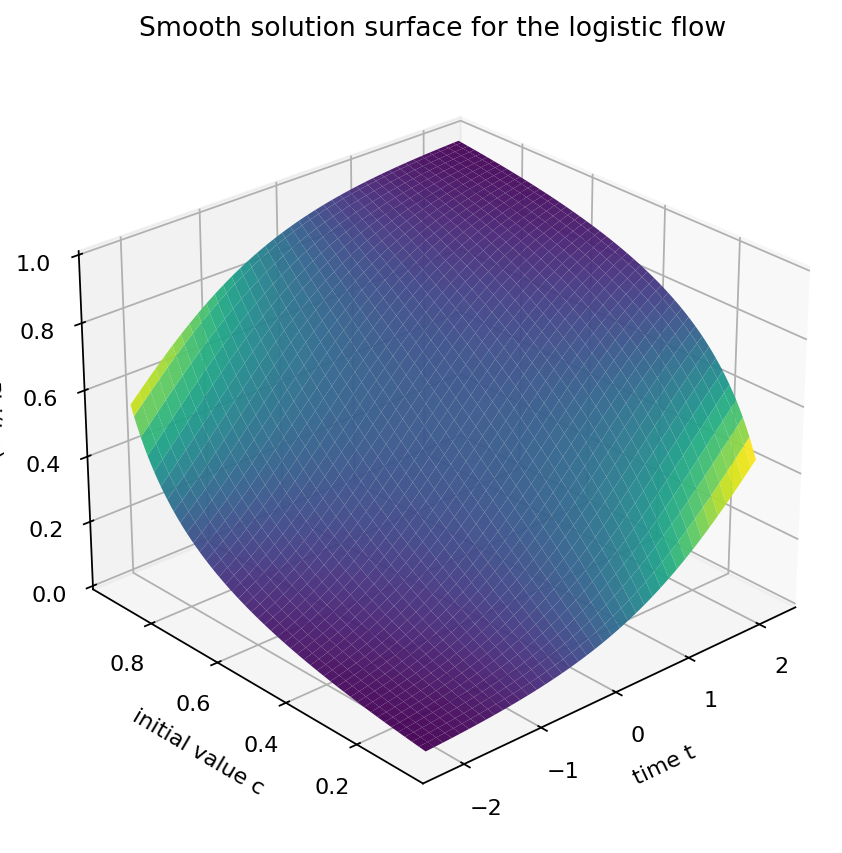

In [7]:
def logistic_phi(t, c):
    et = np.exp(t)
    return c * et / (1.0 - c + c * et)


def logistic_sensitivity(t, c):
    et = np.exp(t)
    return et / (1.0 - c + c * et) ** 2


t_surface = np.linspace(-2.2, 2.2, 120)
c_surface = np.linspace(0.08, 0.92, 90)
TT, CC = np.meshgrid(t_surface, c_surface)
PHI = logistic_phi(TT, CC)
SENS = logistic_sensitivity(TT, CC)

t_s, c_s = sp.symbols("t c", real=True)
phi_expr = c_s * sp.exp(t_s) / (1 - c_s + c_s * sp.exp(t_s))
sens_expr = sp.diff(phi_expr, c_s)
variational_residual = sp.simplify(sp.diff(sens_expr, t_s) - (1 - 2 * phi_expr) * sens_expr)
assert variational_residual == 0

h = 1e-5
finite_difference = (logistic_phi(TT, CC + h) - logistic_phi(TT, CC - h)) / (2 * h)
smooth_dependence_fd_error = float(np.max(np.abs(finite_difference - SENS)))
assert smooth_dependence_fd_error < 1e-8

fig = plt.figure(figsize=(9.2, 6.4))
ax = fig.add_subplot(111, projection="3d")
surface = ax.plot_surface(TT, CC, PHI, facecolors=cm.viridis((SENS - SENS.min()) / (SENS.max() - SENS.min())), linewidth=0, antialiased=True, shade=False, alpha=0.95)
ax.set_title("Smooth solution surface for the logistic flow")
ax.set_xlabel("time t")
ax.set_ylabel("initial value c")
ax.set_zlabel("Phi(t,c)")
ax.view_init(elev=27, azim=-132)
smooth_surface_path = save_figure(fig, "appendix-d-smooth-dependence-surface.png")

plotly_surface = go.Figure(
    data=[
        go.Surface(
            x=TT,
            y=CC,
            z=PHI,
            surfacecolor=SENS,
            colorscale="Viridis",
            colorbar={"title": "dPhi/dc"},
            contours={"z": {"show": True, "usecolormap": True, "highlightcolor": "#0f172a", "project_z": True}},
        )
    ]
)
plotly_surface.update_layout(
    title="Interactive smooth dependence surface",
    scene={"xaxis_title": "t", "yaxis_title": "c", "zaxis_title": "Phi(t,c)"},
    margin={"l": 0, "r": 0, "b": 0, "t": 42},
)
smooth_surface_html_path = save_plotly_standalone(plotly_surface, "appendix-d-smooth-dependence-surface.html")

smooth_check_path = save_check(
    {
        "equation": "y' = y(1-y)",
        "symbolic_variational_residual": str(variational_residual),
        "finite_difference_sensitivity_max_error": smooth_dependence_fd_error,
        "surface_phi_min": float(PHI.min()),
        "surface_phi_max": float(PHI.max()),
        "sensitivity_min": float(SENS.min()),
        "sensitivity_max": float(SENS.max()),
    },
    "appendix-d-smooth-dependence-check.json",
)
display_artifact(smooth_surface_path, width=760)
display_artifact(smooth_surface_html_path, width=820, height=560)


## Nonautonomous Systems as Autonomous Systems in Extended Space

Appendix D reduces `x' = V(t,x)` to an autonomous equation by adding the clock coordinate `s' = 1`. This is not just a formal trick: the time-dependent curve becomes an ordinary integral curve of the lifted field `(1, V(s,x))` in one higher-dimensional space.


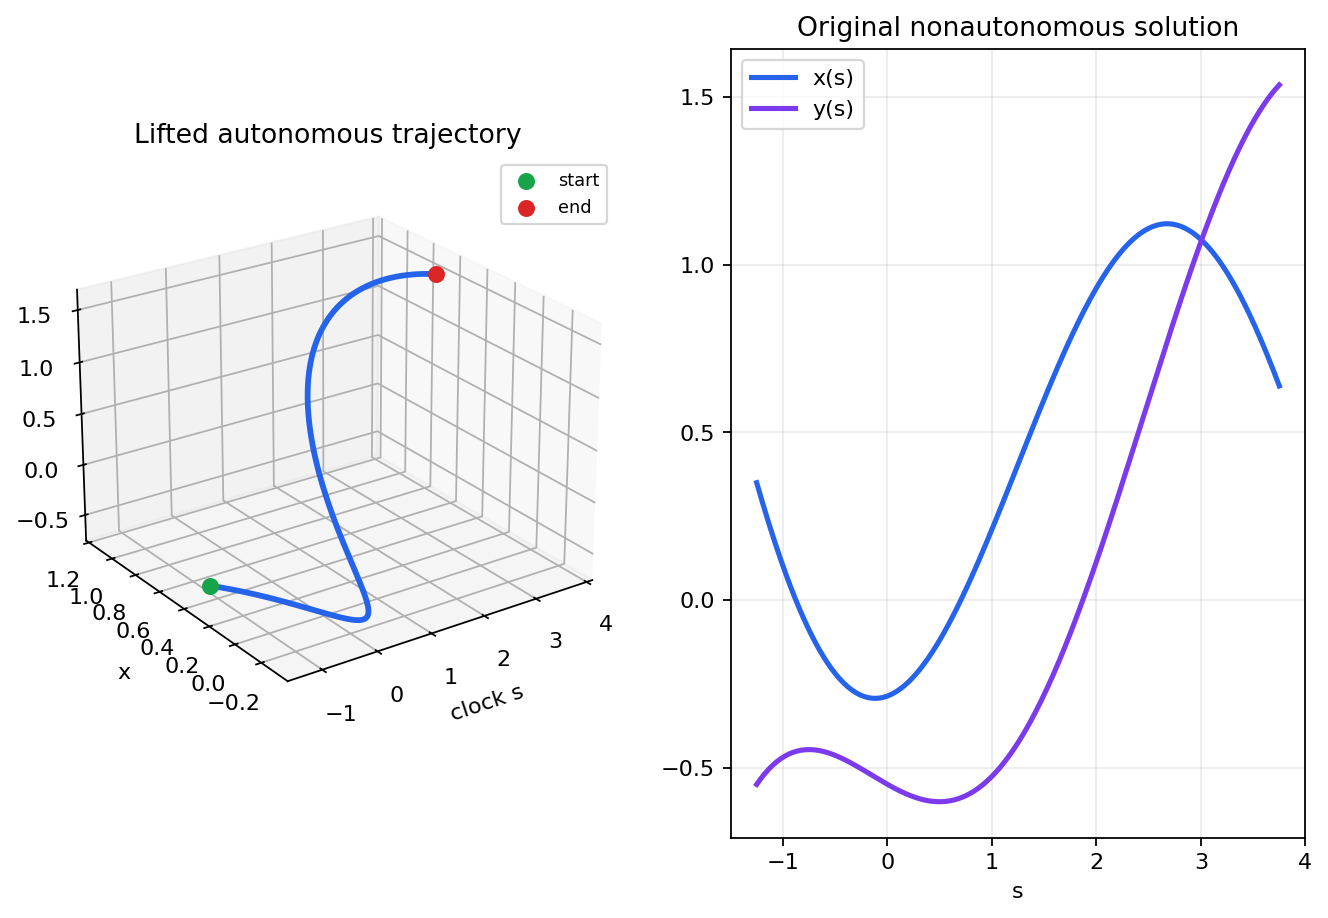

In [8]:
def original_nonauto(s, z):
    x, y = z
    return np.array([np.sin(s) - 0.4 * x, x - 0.2 * y])


def lifted_autonomous(tau, z):
    s_clock, x, y = z
    return np.array([1.0, np.sin(s_clock) - 0.4 * x, x - 0.2 * y])


s_initial = -1.25
state_initial = np.array([0.35, -0.55])
tau_eval = np.linspace(0, 5.0, 260)
lift_sol = solve_ivp(lifted_autonomous, (0, 5.0), [s_initial, *state_initial], t_eval=tau_eval, rtol=1e-10, atol=1e-12)
orig_sol = solve_ivp(original_nonauto, (s_initial, s_initial + 5.0), state_initial, t_eval=s_initial + tau_eval, rtol=1e-10, atol=1e-12)
assert lift_sol.success and orig_sol.success

clock_error = float(np.max(np.abs(lift_sol.y[0] - (s_initial + tau_eval))))
coordinate_error = float(np.max(np.linalg.norm(lift_sol.y[1:] - orig_sol.y, axis=0)))
assert clock_error < 1e-10
assert coordinate_error < 1e-8

fig = plt.figure(figsize=(10.2, 6.4))
ax = fig.add_subplot(121, projection="3d")
ax.plot(lift_sol.y[0], lift_sol.y[1], lift_sol.y[2], color="#2563eb", lw=2.6)
ax.scatter([lift_sol.y[0, 0]], [lift_sol.y[1, 0]], [lift_sol.y[2, 0]], color="#16a34a", s=44, label="start")
ax.scatter([lift_sol.y[0, -1]], [lift_sol.y[1, -1]], [lift_sol.y[2, -1]], color="#dc2626", s=44, label="end")
ax.set_title("Lifted autonomous trajectory")
ax.set_xlabel("clock s")
ax.set_ylabel("x")
ax.set_zlabel("y")
ax.legend(fontsize=8)
ax.view_init(elev=24, azim=-125)

ax2 = fig.add_subplot(122)
ax2.plot(orig_sol.t, orig_sol.y[0], color="#2563eb", lw=2.3, label="x(s)")
ax2.plot(orig_sol.t, orig_sol.y[1], color="#7c3aed", lw=2.3, label="y(s)")
ax2.set_title("Original nonautonomous solution")
ax2.set_xlabel("s")
ax2.grid(alpha=0.25)
ax2.legend()

lift_path = save_figure(fig, "appendix-d-nonautonomous-autonomous-lift.png")
lift_check_path = save_check(
    {
        "original_system": "x' = sin(s) - 0.4x, y' = x - 0.2y",
        "lifted_system": "s' = 1, x' = sin(s) - 0.4x, y' = x - 0.2y",
        "clock_error": clock_error,
        "coordinate_error_against_original": coordinate_error,
    },
    "appendix-d-nonautonomous-lift-check.json",
)
display_artifact(lift_path, width=900)


## `2x2` Constant-Coefficient Linear Systems

A system `Z' = A Z` is solved by the matrix exponential `Z(t)=exp(tA)Z(0)`. For `2x2` real matrices, the trace, determinant, and discriminant sort the local portraits: saddles, nodes, spirals, centers, and repeated-root cases. The static figure shows representative phase portraits; the HTML artifact marks the same examples in the trace-determinant plane.


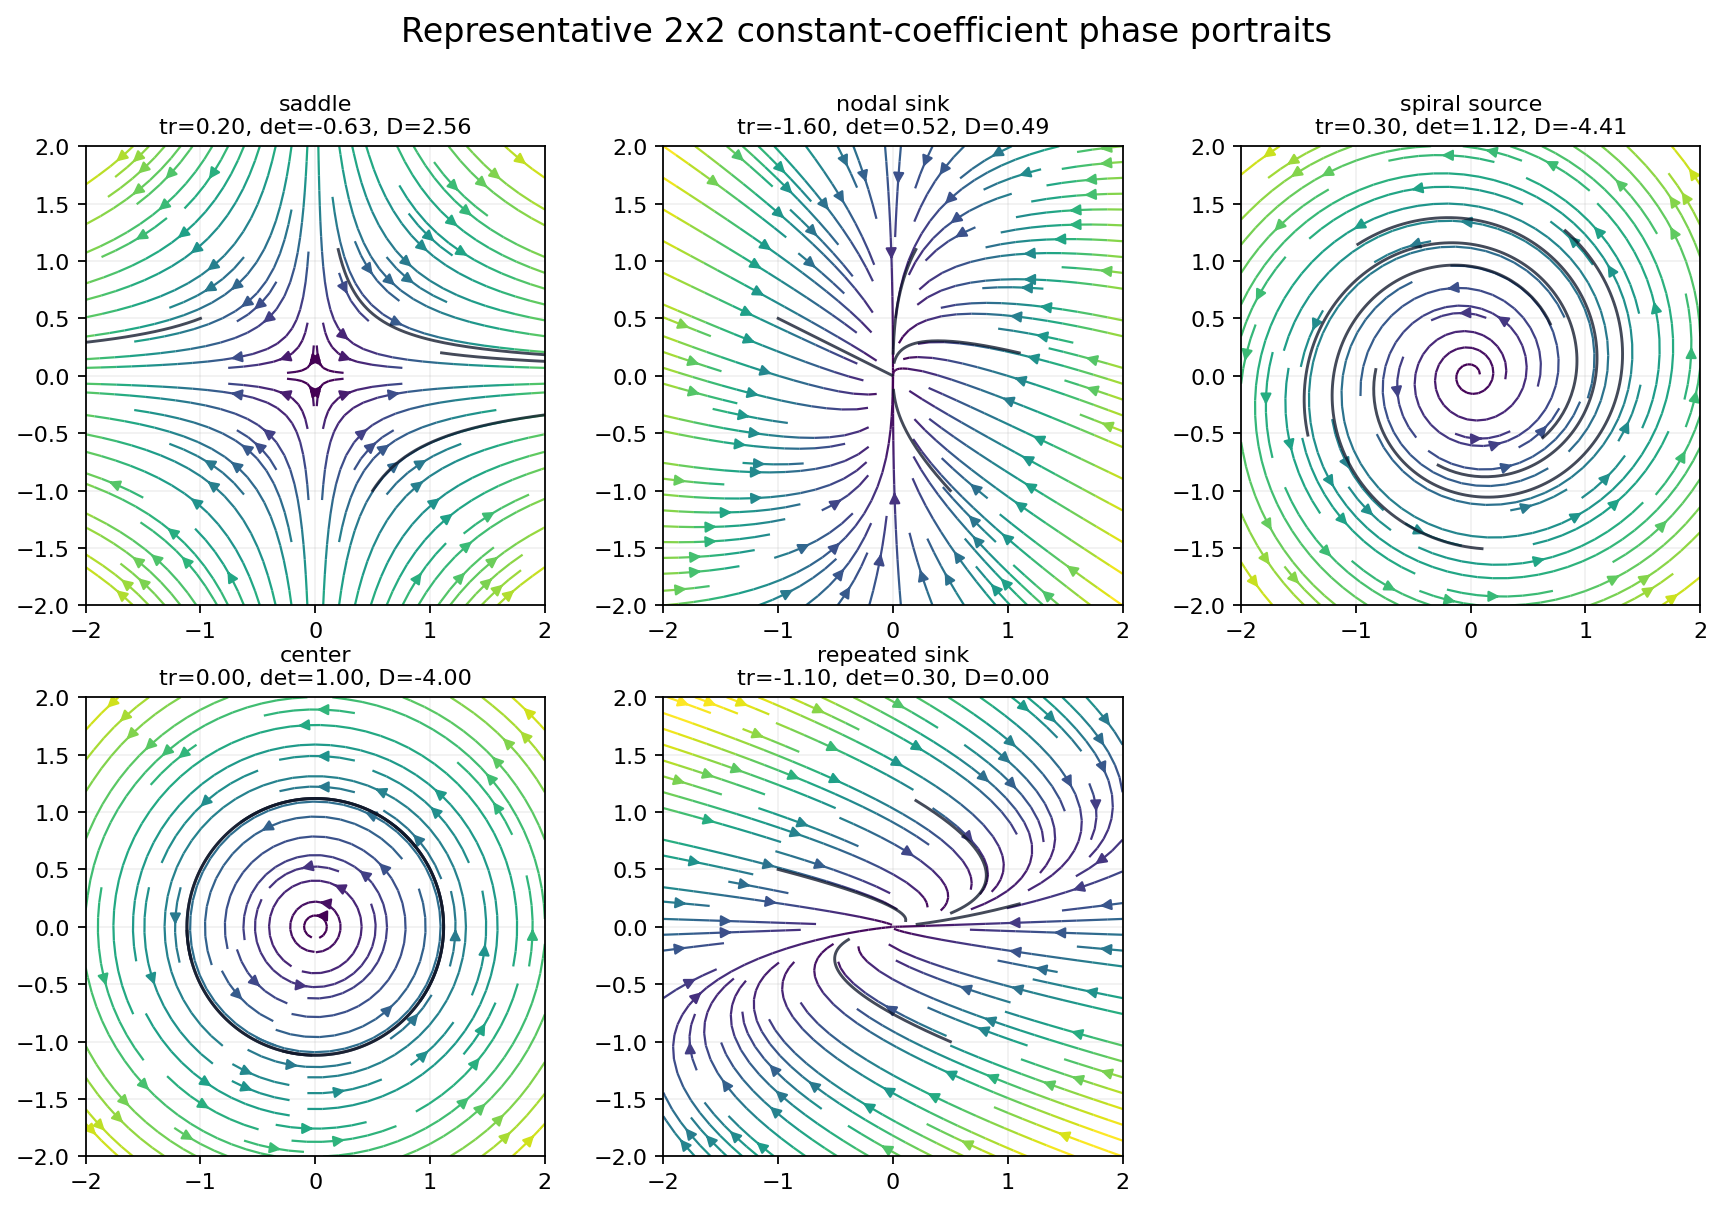

[appendix-d-2x2-classifier-table.csv](D:/Geometry/Introduction-to-Smooth-Manifolds/artifacts/appendix-d-review-of-differential-equations/tables/appendix-d-2x2-classifier-table.csv)

In [9]:
def classify_matrix(A, tol=1e-9):
    A = np.array(A, dtype=float)
    tr = float(np.trace(A))
    det = float(np.linalg.det(A))
    disc = tr * tr - 4.0 * det
    eig = np.linalg.eigvals(A)
    if det < -tol:
        label = "saddle"
    elif abs(det) <= tol:
        label = "degenerate"
    elif disc < -tol:
        if tr > tol:
            label = "spiral source"
        elif tr < -tol:
            label = "spiral sink"
        else:
            label = "center"
    elif disc > tol:
        if tr > tol:
            label = "nodal source"
        elif tr < -tol:
            label = "nodal sink"
        else:
            label = "real distinct neutral"
    else:
        if tr > tol:
            label = "repeated source"
        elif tr < -tol:
            label = "repeated sink"
        else:
            label = "nilpotent/repeated zero"
    return {
        "trace": tr,
        "determinant": det,
        "discriminant": float(disc),
        "eigenvalues": [complex(v) for v in eig],
        "classification": label,
    }


systems = [
    ("saddle", np.array([[0.9, 0.0], [0.0, -0.7]])),
    ("nodal sink", np.array([[-1.15, 0.0], [0.35, -0.45]])),
    ("spiral source", np.array([[0.15, -1.05], [1.05, 0.15]])),
    ("center", np.array([[0.0, -1.0], [1.0, 0.0]])),
    ("repeated sink", np.array([[-0.55, 1.0], [0.0, -0.55]])),
]

classifier_rows = []
for name, A in systems:
    info = classify_matrix(A)
    classifier_rows.append(
        {
            "example": name,
            "trace": info["trace"],
            "determinant": info["determinant"],
            "discriminant": info["discriminant"],
            "classification": info["classification"],
            "eigenvalues": "; ".join(f"{v.real:.4g}{v.imag:+.4g}j" for v in info["eigenvalues"]),
        }
    )

phase_table_path = save_table(classifier_rows, "appendix-d-2x2-classifier-table.csv")

fig, axes = plt.subplots(2, 3, figsize=(13.2, 8.2))
axes = axes.ravel()
seed_points = [np.array([1.1, 0.2]), np.array([0.2, 1.1]), np.array([-1.0, 0.5]), np.array([0.5, -1.0])]
for ax, (name, A) in zip(axes, systems):
    x = np.linspace(-2.0, 2.0, 24)
    y = np.linspace(-2.0, 2.0, 24)
    X, Y = np.meshgrid(x, y)
    U = A[0, 0] * X + A[0, 1] * Y
    V = A[1, 0] * X + A[1, 1] * Y
    speed = np.sqrt(U**2 + V**2)
    ax.streamplot(X, Y, U, V, color=np.clip(speed, 0, 3), cmap="viridis", density=1.0, linewidth=1.0, arrowsize=1.0)
    times = np.linspace(0, 4.0, 130)
    if "source" in classify_matrix(A)["classification"] or name == "center":
        times = np.linspace(-2.0, 2.0, 130)
    for z0 in seed_points:
        curve = np.array([expm(tau * A) @ z0 for tau in times])
        ax.plot(curve[:, 0], curve[:, 1], color="#0f172a", lw=1.3, alpha=0.78)
    info = classify_matrix(A)
    ax.set_title(f"{name}\ntr={info['trace']:.2f}, det={info['determinant']:.2f}, D={info['discriminant']:.2f}", fontsize=10)
    ax.set_xlim(-2, 2)
    ax.set_ylim(-2, 2)
    ax.set_aspect("equal")
    ax.grid(alpha=0.18)
axes[-1].axis("off")
fig.suptitle("Representative 2x2 constant-coefficient phase portraits", fontsize=15, y=0.98)
phase_portrait_path = save_figure(fig, "appendix-d-2x2-phase-portraits.png")

trace_line = np.linspace(-3.0, 3.0, 300)
parabola = trace_line**2 / 4.0
fig_td = go.Figure()
fig_td.add_trace(go.Scatter(x=trace_line, y=parabola, mode="lines", name="D = 0", line={"color": "#0f172a", "dash": "dash"}))
fig_td.add_trace(go.Scatter(x=trace_line, y=np.zeros_like(trace_line), mode="lines", name="det = 0", line={"color": "#64748b"}))
fig_td.add_trace(
    go.Scatter(
        x=[row["trace"] for row in classifier_rows],
        y=[row["determinant"] for row in classifier_rows],
        text=[row["classification"] for row in classifier_rows],
        mode="markers+text",
        textposition="top center",
        marker={"size": 12, "color": ["#dc2626", "#2563eb", "#ea580c", "#16a34a", "#7c3aed"]},
        name="examples",
    )
)
fig_td.update_layout(
    title="Trace-determinant classifier for 2x2 systems",
    xaxis_title="trace(A)",
    yaxis_title="det(A)",
    yaxis_range=[-2.0, 4.2],
    margin={"l": 50, "r": 20, "t": 50, "b": 45},
)
phase_classifier_html_path = save_plotly_standalone(fig_td, "appendix-d-2x2-trace-determinant-classifier.html")

residuals = []
for _, A in systems:
    for z0 in seed_points:
        tau = 0.7
        h = 1e-5
        numeric_derivative = (expm((tau + h) * A) @ z0 - expm((tau - h) * A) @ z0) / (2 * h)
        exact_rhs = A @ (expm(tau * A) @ z0)
        residuals.append(float(np.linalg.norm(numeric_derivative - exact_rhs)))
matrix_exp_residual = float(max(residuals))
assert matrix_exp_residual < 1e-9

linear_check_path = save_check(
    {
        "classifications": classifier_rows,
        "matrix_exponential_derivative_max_residual": matrix_exp_residual,
        "trace_determinant_rule": "det < 0 gives saddle; det > 0 with negative discriminant gives spirals/center; positive discriminant gives nodes",
    },
    "appendix-d-2x2-linear-system-check.json",
)
display_artifact(phase_portrait_path, width=920)
display_artifact(phase_classifier_html_path, width=820, height=520)
display_artifact(phase_table_path)


## Flows, Maximal Intervals, and the Partial Group Law

For the vector field `x^2 d/dx` on the line, the local flow is `Phi_t(x)=x/(1-tx)`. The denominator records the maximal interval: a positive initial value blows up at positive time `1/x`, while a negative one blows up at negative time. The composition law is exact, but only on the common domain where every expression is defined.


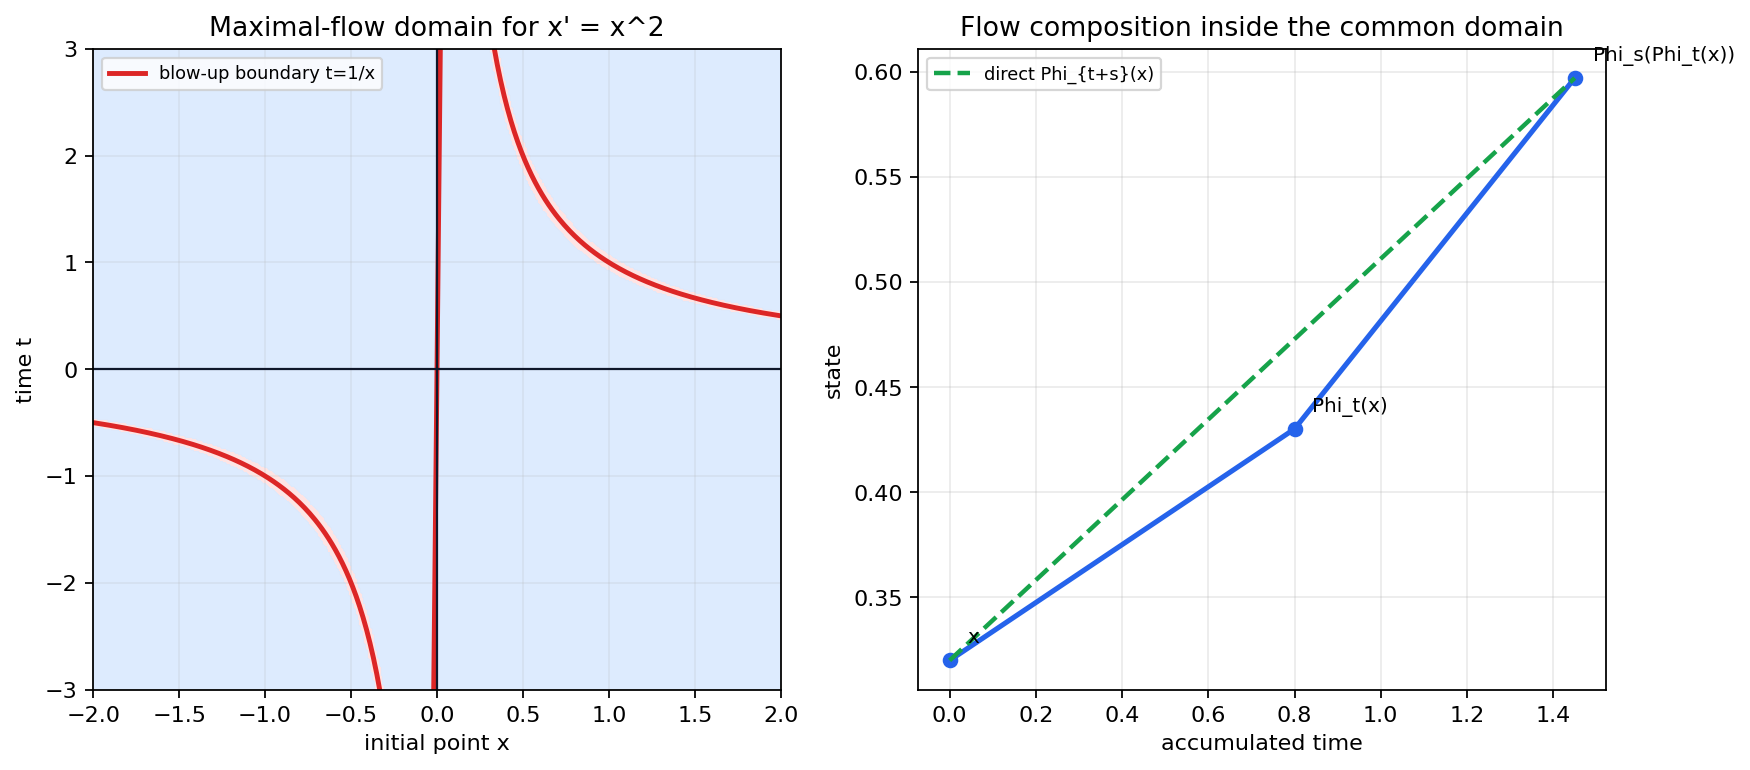

In [10]:
x_sym, t_sym, s_sym = sp.symbols("x t s", real=True)
phi_expr = lambda tau, z: sp.simplify(z / (1 - tau * z))
flow_law_residual = sp.simplify(phi_expr(s_sym, phi_expr(t_sym, x_sym)) - phi_expr(t_sym + s_sym, x_sym))
inverse_residual = sp.simplify(phi_expr(-t_sym, phi_expr(t_sym, x_sym)) - x_sym)
assert flow_law_residual == 0
assert inverse_residual == 0

x_vals = np.linspace(-2.0, 2.0, 401)
t_vals = np.linspace(-3.0, 3.0, 401)
XX, TT = np.meshgrid(x_vals, t_vals)
denominator = 1.0 - TT * XX
domain_mask = np.abs(denominator) > 0.08

fig, axes = plt.subplots(1, 2, figsize=(12.2, 5.2))
axes[0].contourf(XX, TT, domain_mask.astype(float), levels=[-0.1, 0.5, 1.1], colors=["#fee2e2", "#dbeafe"], alpha=0.92)
nonzero_x = x_vals[np.abs(x_vals) > 0.08]
axes[0].plot(nonzero_x, 1.0 / nonzero_x, color="#dc2626", lw=2.2, label="blow-up boundary t=1/x")
axes[0].axhline(0, color="#0f172a", lw=1)
axes[0].axvline(0, color="#0f172a", lw=1)
axes[0].set_xlim(-2, 2)
axes[0].set_ylim(-3, 3)
axes[0].set_title("Maximal-flow domain for x' = x^2")
axes[0].set_xlabel("initial point x")
axes[0].set_ylabel("time t")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.18)

def phi_numeric(tau, z):
    return z / (1.0 - tau * z)


x0 = 0.32
t1 = 0.8
t2 = 0.65
first = phi_numeric(t1, x0)
second = phi_numeric(t2, first)
direct = phi_numeric(t1 + t2, x0)
composition_error = float(abs(second - direct))

points = [(0.0, x0, "x"), (t1, first, "Phi_t(x)"), (t1 + t2, second, "Phi_s(Phi_t(x))")]
axes[1].plot([p[0] for p in points], [p[1] for p in points], color="#2563eb", lw=2.3, marker="o")
for tau, value, label in points:
    axes[1].annotate(label, (tau, value), xytext=(8, 8), textcoords="offset points", fontsize=9)
axes[1].plot([0, t1 + t2], [x0, direct], color="#16a34a", ls="--", lw=2, label="direct Phi_{t+s}(x)")
axes[1].set_title("Flow composition inside the common domain")
axes[1].set_xlabel("accumulated time")
axes[1].set_ylabel("state")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

flow_path = save_figure(fig, "appendix-d-flow-composition-maximal-interval.png")
flow_check_path = save_check(
    {
        "field": "x^2 d/dx",
        "flow": "Phi_t(x)=x/(1-tx)",
        "symbolic_flow_law_residual": str(flow_law_residual),
        "symbolic_inverse_residual": str(inverse_residual),
        "composition_error_at_sample": composition_error,
        "sample_denominators": {
            "1 - t*x": float(1 - t1 * x0),
            "1 - s*Phi_t(x)": float(1 - t2 * first),
            "1 - (t+s)*x": float(1 - (t1 + t2) * x0),
        },
    },
    "appendix-d-flow-composition-check.json",
)
display_artifact(flow_path, width=900)


## Applied Lab: Classify and Test a New Linear Flow

The small function below is meant to be edited. Change `lab_A`, rerun the cell, and compare the classifier to the visible eigenvalues. The residual check asks whether the matrix exponential is actually solving `Z'=AZ`.


In [11]:
lab_A = np.array([[0.0, -2.0], [1.0, -0.25]])
lab_info = classify_matrix(lab_A)
lab_z0 = np.array([1.0, -0.4])
lab_tau = 1.15
lab_h = 1e-5
lab_numeric_derivative = (expm((lab_tau + lab_h) * lab_A) @ lab_z0 - expm((lab_tau - lab_h) * lab_A) @ lab_z0) / (2 * lab_h)
lab_exact_rhs = lab_A @ (expm(lab_tau * lab_A) @ lab_z0)
lab_residual = float(np.linalg.norm(lab_numeric_derivative - lab_exact_rhs))
assert lab_residual < 1e-9

lab_check_path = save_check(
    {
        "matrix": lab_A.tolist(),
        "classification": lab_info["classification"],
        "trace": lab_info["trace"],
        "determinant": lab_info["determinant"],
        "discriminant": lab_info["discriminant"],
        "matrix_exponential_residual": lab_residual,
    },
    "appendix-d-applied-lab-linear-flow-check.json",
)
print(json.dumps(json.loads(lab_check_path.read_text(encoding="utf-8")), indent=2))


{
  "classification": "spiral sink",
  "determinant": 2.0,
  "discriminant": -7.9375,
  "matrix": [
    [
      0.0,
      -2.0
    ],
    [
      1.0,
      -0.25
    ]
  ],
  "matrix_exponential_residual": 4.666634560530684e-11,
  "trace": -0.25
}


## Final Sanity Checks

The final cell checks that every generated artifact exists, the main exact identities vanish, comparison bounds are respected, and the numerical validations have small residuals.


In [12]:
all_paths = generated_artifacts + check_paths
assert_artifacts(all_paths, min_bytes=80)

summary = {
    "artifact_count": len(generated_artifacts),
    "check_count": len(check_paths),
    "artifacts": [rel(path) for path in generated_artifacts],
    "checks": [rel(path) for path in check_paths],
    "core_validations": {
        "rotation_residual_zero": rotation_residual == sp.Matrix([0, 0]),
        "picard_observed_ratio_below_bound": observed_max_ratio < L_bound * epsilon + 0.03,
        "gronwall_bound_violation": bound_violation,
        "smooth_dependence_fd_error": smooth_dependence_fd_error,
        "nonautonomous_lift_coordinate_error": coordinate_error,
        "matrix_exponential_residual": matrix_exp_residual,
        "flow_law_residual": str(flow_law_residual),
        "flow_composition_error": composition_error,
    },
}

assert summary["core_validations"]["rotation_residual_zero"]
assert summary["core_validations"]["picard_observed_ratio_below_bound"]
assert bound_violation <= 1e-10
assert smooth_dependence_fd_error < 1e-8
assert coordinate_error < 1e-8
assert matrix_exp_residual < 1e-9
assert flow_law_residual == 0
assert composition_error < 1e-12

final_sanity_path = save_check(summary, "appendix-d-final-sanity.json")
assert_artifacts([final_sanity_path], min_bytes=160)
display_artifact(final_sanity_path)
print(f"Validated {len(all_paths) + 1} Appendix D artifact/check files.")


`appendix-d-final-sanity.json`

Validated 24 Appendix D artifact/check files.


## Takeaways

- Appendix D is the analytic backbone for manifold vector fields: coordinate ODEs give integral curves and local flows.
- Local existence is a fixed point theorem in disguise; the short time interval is chosen so the integral operator is a contraction.
- Uniqueness is a comparison estimate. Locally Lipschitz control prevents two solutions with the same initial value from separating.
- Smooth dependence is captured by the variational equation along a solution.
- Nonautonomous systems become autonomous after adding a clock coordinate.
- The `2x2` linear case is a compact laboratory where eigenvalues, matrix exponentials, and phase portraits agree.
- A local flow is a partial action: `Phi_s(Phi_t(x)) = Phi_{s+t}(x)` only where all terms are defined.
